In [1]:
!pip install lingua-language-detector -q
!pip install deep-translator -q
!pip install thefuzz -q
!pip install python-Levenshtein -q
!pip install faiss-cpu sentence-transformers vaderSentiment -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.7 MB/s eta 0:00:00


# Libraries and Imports

In [2]:
# Install all required libraries before importing.
# scipy is used for statistical significance testing.
# statsmodels is new here - used for Tukey HSD post-hoc testing.
# scikit-learn is used for TF-IDF vectorization and NMF topic modeling.


from google.colab import drive
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from importlib import reload

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Define all directory paths
BASE_DIR   = '/content/drive/Shareddrives/essentis_intern_drive'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
SRC_DIR    = os.path.join(DATA_DIR, 'src_reviews_cleaning')
CHARTS_DIR = os.path.join(BASE_DIR, 'charts', 'statistical')
EXPORT_DIR = os.path.join(BASE_DIR, 'charts', 'statistical', 'exports')

# Add the data directory to sys.path so Python can find the pipeline package
if DATA_DIR not in sys.path:
    sys.path.insert(0, DATA_DIR)

# Create output directories if they do not already exist
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)

# Apply a consistent visual theme to all charts
sns.set_theme()

print("Setup complete.")
print("SRC_DIR exists:  ", os.path.exists(SRC_DIR))
print("CHARTS_DIR:      ", CHARTS_DIR)
print("EXPORT_DIR:      ", EXPORT_DIR)

Mounted at /content/drive
Setup complete.
SRC_DIR exists:   True
CHARTS_DIR:       /content/drive/Shareddrives/essentis_intern_drive/charts/statistical
EXPORT_DIR:       /content/drive/Shareddrives/essentis_intern_drive/charts/statistical/exports


# Load Data

In [3]:
# Load the cleaned reviews DataFrame directly from the pipeline.
# This ensures the analysis always uses the most current version of the data.
# text_for_analysis uses translated text for non-English reviews so all
# downstream text analysis runs on English text only.

import src_reviews_cleaning.pipeline as P
reload(P)

df = P.run(save_csv=False)

# Use translated text for non-English reviews, original for English
df['text_for_analysis'] = df['review_text_translated'].where(
    df['review_text_translated'].notna(), df['review_text']
)

# Drop rows with no usable text
df = df.dropna(subset=['text_for_analysis']).reset_index(drop=True)

# Extract year and month for time trend analysis
df['review_year']  = df['review_date'].dt.year
df['review_month'] = df['review_date'].dt.to_period('M')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nReview year range:", df['review_year'].min(), "to", df['review_year'].max())
print("\nCourse value counts:")
print(df['course'].value_counts(dropna=False).to_string())

/content/drive/Shareddrives/essentis_intern_drive/data/src_reviews_cleaning/cleaners.py:70: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("(a|[0-9]+)\s+(day|week|month|year)s?\s+ago", relative)


Step 1/4: Loading raw data...
  google: 256 rows
  clean: 541 rows
  new: 49 rows
Step 2/4: Normalizing columns...


/content/drive/Shareddrives/essentis_intern_drive/data/src_reviews_cleaning/normalizers.py:297: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(normalized, ignore_index=True)


  Combined shape: (846, 17)
Step 3/4: Cleaning data (includes language detection + translation)...
  [17/846] Translated from FRENCH: Très bonne école de formation. Les cours sont bien...
  [206/846] Translated from GERMAN: Der KI Kompaktkurs bei WBS Coding School bietet ei...
  [207/846] Translated from GERMAN: Abhängig vom eigenen Skillset und der jeweiligen G...
  [208/846] Translated from GERMAN: Der AI Compact-Kurs war ausgezeichnet. Er hat mir ...
  [209/846] Translated from GERMAN: Von Mai bis Juli 2025 habe ich an der WBS eine Wei...
  [210/846] Translated from GERMAN: Das Bootcamp "AI for Business" war für mich ein ec...
  [211/846] Translated from GERMAN: Ich habe den Data Science-Kurs abgeschlossen und e...
  [212/846] Translated from GERMAN: Anfangs war ich unsicher, ob mein Vorwissen für da...
  [213/846] Translated from GERMAN: Ich bin mit wenig Programmier-Erfahrung ins Data S...
  [214/846] Translated from GERMAN: Ich habe in den letzten 8 Wochen am KI-Kurs der WB...
  

# Establish Threshold

=== REVIEW COUNTS PER COURSE ===
                    course  review_count
      Full-Stack Web & App           314
              Data Science           182
            Product Design            24
       Marketing Analytics            16
Full-Stack PHP Development             2

=== STANDARD ERROR OF MEAN RATING BY COURSE ===
                    course   n  mean_rating   std    sem
      Full-Stack Web & App 314        4.706 0.513 0.0289
              Data Science 182        4.776 0.440 0.0326
            Product Design  24        4.690 0.409 0.0835
       Marketing Analytics  16        4.743 0.329 0.0823
Full-Stack PHP Development   2        4.175 0.106 0.0750


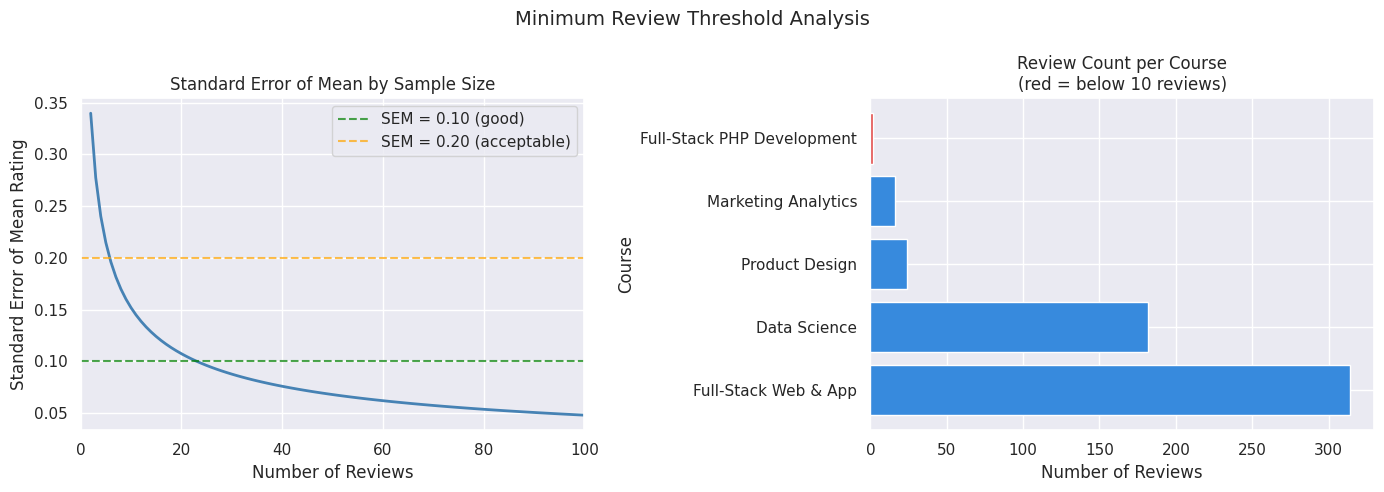

Saved: minimum_threshold_analysis.png

Minimum review threshold set to: 10
Courses included in statistical tests:
  Included: ['Full-Stack Web & App', 'Data Science', 'Product Design', 'Marketing Analytics']
  Excluded: ['Full-Stack PHP Development']


In [4]:
# Determine the appropriate minimum number of reviews per course to include
# in statistical tests. Including courses with very few reviews risks drawing
# conclusions from statistically unreliable samples.
#
# This cell examines the distribution of review counts per course and uses
# the following approach to decide the threshold:
#   - Print counts per course so we can see the distribution
#   - Calculate the standard error of the mean for each course at different
#     thresholds to show how reliability improves with more reviews
#   - Recommend a threshold based on where the standard error stabilizes
#
# The chosen threshold is stored in MIN_REVIEWS and used in all
# subsequent statistical tests throughout this notebook.

course_counts = df.dropna(subset=['course'])['course'].value_counts().reset_index()
course_counts.columns = ['course', 'review_count']

print("=== REVIEW COUNTS PER COURSE ===")
print(course_counts.to_string(index=False))

# Calculate standard error of the mean rating at each sample size
# Standard error = std / sqrt(n). Lower SEM = more reliable estimate.
print("\n=== STANDARD ERROR OF MEAN RATING BY COURSE ===")
sem_data = []
for _, row in course_counts.iterrows():
    course_df = df[df['course'] == row['course']]['overall_experience'].dropna()
    sem = course_df.sem() if len(course_df) > 1 else np.nan
    sem_data.append({
        'course':       row['course'],
        'n':            len(course_df),
        'mean_rating':  round(course_df.mean(), 3),
        'std':          round(course_df.std(), 3),
        'sem':          round(sem, 4) if not np.isnan(sem) else np.nan,
    })
sem_df = pd.DataFrame(sem_data).sort_values('n', ascending=False)
print(sem_df.to_string(index=False))

# Simulate how SEM changes as sample size increases
# This helps visualize where the reliability curve flattens
sim_ns    = list(range(2, 101))
# Use the pooled std across all courses as a representative value
pooled_std = df.dropna(subset=['course'])['overall_experience'].std()
sim_sems  = [pooled_std / np.sqrt(n) for n in sim_ns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Minimum Review Threshold Analysis", fontsize=14)

# SEM curve — shows where reliability stabilizes
axes[0].plot(sim_ns, sim_sems, color='steelblue', linewidth=2)
axes[0].axhline(0.1, color='green',  linestyle='--', alpha=0.7, label='SEM = 0.10 (good)')
axes[0].axhline(0.2, color='orange', linestyle='--', alpha=0.7, label='SEM = 0.20 (acceptable)')
axes[0].set_title("Standard Error of Mean by Sample Size")
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Standard Error of Mean Rating")
axes[0].legend()
axes[0].set_xlim(0, 100)

# Bar chart of actual review counts per course
colors = ['#378ADD' if n >= 10 else '#E24B4A' for n in course_counts['review_count']]
axes[1].barh(course_counts['course'], course_counts['review_count'], color=colors)
axes[1].set_title("Review Count per Course\n(red = below 10 reviews)")
axes[1].set_xlabel("Number of Reviews")
axes[1].set_ylabel("Course")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'minimum_threshold_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: minimum_threshold_analysis.png")

# Set the minimum threshold based on SEM analysis
# At n=10 SEM is around 0.2 which is acceptable for comparative analysis
# At n=30 SEM drops to around 0.1 which is good - but would exclude some courses
# We use 10 as the threshold to retain all meaningful courses
MIN_REVIEWS = 10
print(f"\nMinimum review threshold set to: {MIN_REVIEWS}")
print(f"Courses included in statistical tests:")
included = course_counts[course_counts['review_count'] >= MIN_REVIEWS]['course'].tolist()
excluded = course_counts[course_counts['review_count'] < MIN_REVIEWS]['course'].tolist()
print(f"  Included: {included}")
print(f"  Excluded: {excluded}")

# Overall Experience over time

=== AVERAGE RATINGS BY YEAR ===
 review_year  overall_experience  review  instructors  curriculum  job_assistance
      2020.0               4.854   4.878        4.909       4.783           4.826
      2021.0               4.791   4.880        4.872       4.753           4.643
      2022.0               4.707   4.786        4.635       4.725           4.596
      2023.0               4.778   4.830        4.898       4.834           4.444
      2024.0               4.815   4.866        4.938       4.789           4.489
      2025.0               4.712   4.744          NaN       4.727           4.634


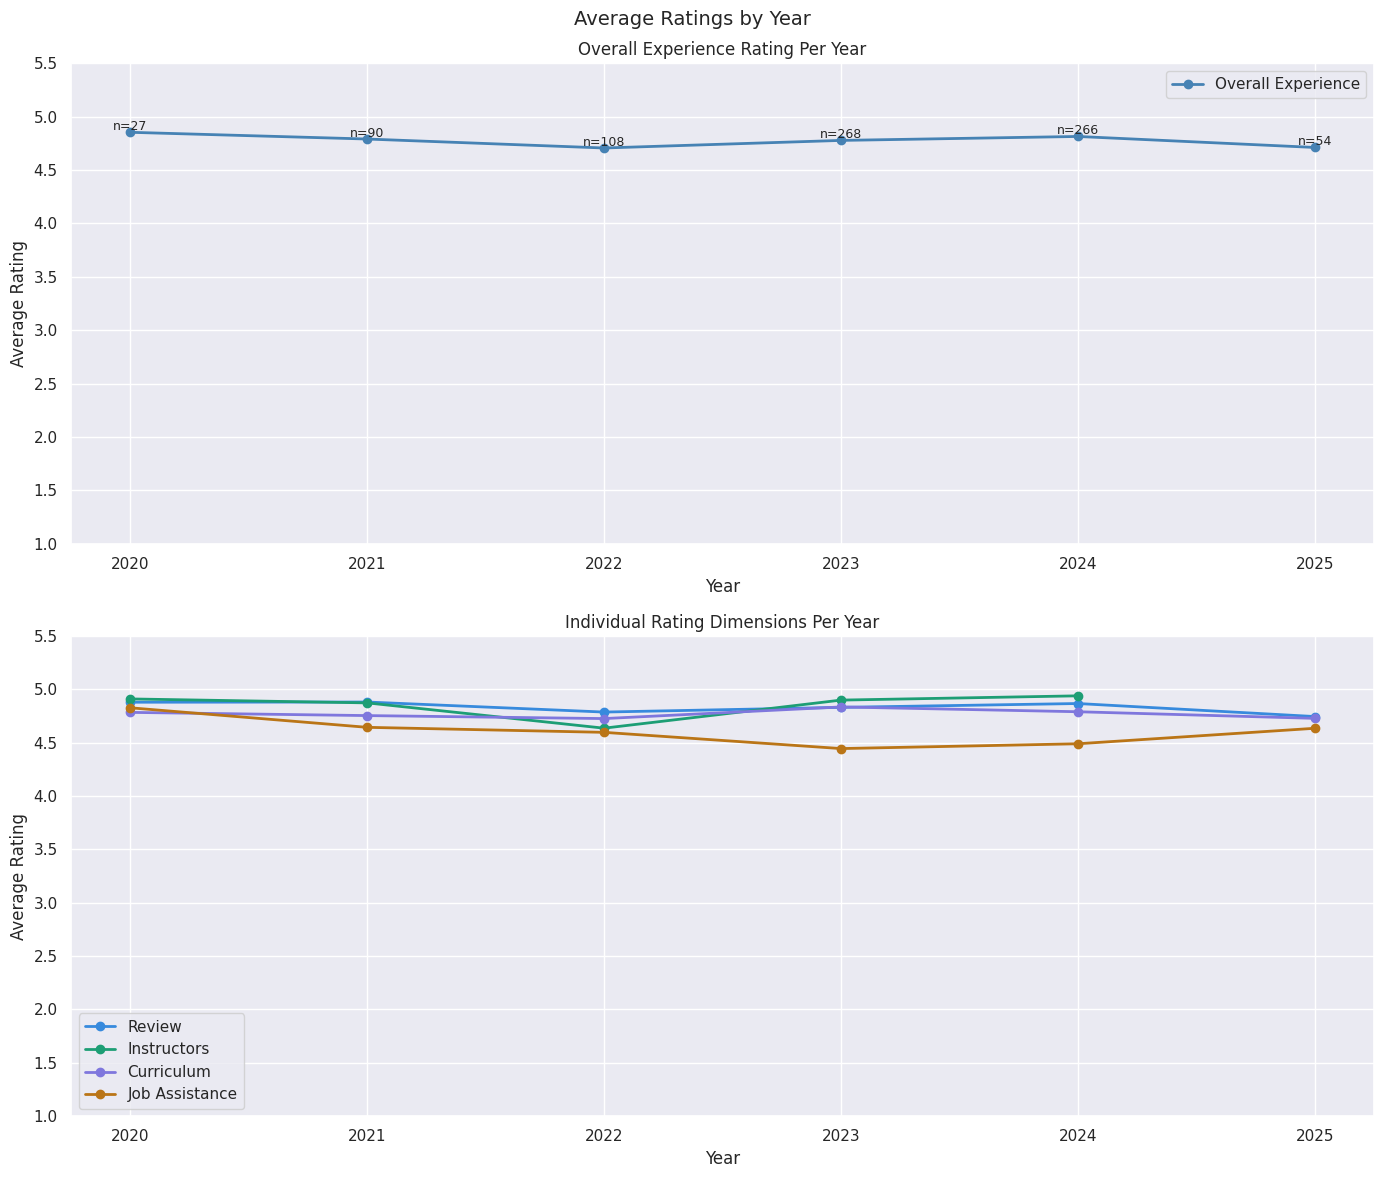

Saved: average_ratings_by_year.png
Saved: yearly_rating_averages.csv


In [5]:
# Calculate average ratings per year across all four rating dimensions.
# This is different from the sentiment time trend — here we are looking at
# the raw numeric star ratings rather than VADER compound scores.
# Examining all four rating dimensions separately reveals whether specific
# aspects of the course are improving or declining independently of others.
#
# Only years with at least 10 reviews are included to ensure reliability.

# Filter to rows with valid ratings and dates
ratings_time_df = df.dropna(subset=['review_year', 'overall_experience']).copy()

# Count reviews per year to apply minimum threshold
year_counts = ratings_time_df['review_year'].value_counts()
valid_years = year_counts[year_counts >= MIN_REVIEWS].index
ratings_time_df = ratings_time_df[ratings_time_df['review_year'].isin(valid_years)]

# Calculate average of each rating dimension per year
RATING_COLS = ['overall_experience', 'review', 'instructors', 'curriculum', 'job_assistance']
yearly_avg  = ratings_time_df.groupby('review_year')[RATING_COLS].mean().round(3).reset_index()

print("=== AVERAGE RATINGS BY YEAR ===")
print(yearly_avg.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle("Average Ratings by Year", fontsize=14)

# Overall experience trend
axes[0].plot(
    yearly_avg['review_year'], yearly_avg['overall_experience'],
    marker='o', color='steelblue', linewidth=2, label='Overall Experience'
)
# Annotate each point with review count
for year in yearly_avg['review_year']:
    n = len(ratings_time_df[ratings_time_df['review_year'] == year])
    y = yearly_avg[yearly_avg['review_year'] == year]['overall_experience'].values[0]
    axes[0].annotate(f"n={n}", (year, y + 0.02), ha='center', fontsize=9)
axes[0].set_title("Overall Experience Rating Per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Rating")
axes[0].set_ylim(1, 5.5)
axes[0].set_xticks(sorted(valid_years))
axes[0].legend()

# All four dimensions as separate lines
colors_map = {
    'review':        '#378ADD',
    'instructors':   '#1D9E75',
    'curriculum':    '#7F77DD',
    'job_assistance':'#BA7517',
}
for col, color in colors_map.items():
    valid = yearly_avg.dropna(subset=[col])
    axes[1].plot(
        valid['review_year'], valid[col],
        marker='o', color=color, linewidth=2,
        label=col.replace('_', ' ').title()
    )
axes[1].set_title("Individual Rating Dimensions Per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(1, 5.5)
axes[1].set_xticks(sorted(valid_years))
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'average_ratings_by_year.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: average_ratings_by_year.png")

# Save yearly averages to export
yearly_avg.to_csv(os.path.join(EXPORT_DIR, 'yearly_rating_averages.csv'), index=False)
print("Saved: yearly_rating_averages.csv")

# Welch's Test for Satistical significance

=== WELCH T-TEST — PAIRWISE COURSE COMPARISONS ===
Rating metric: overall_experience
Significance threshold: p < 0.05

            course_a            course_b  mean_a  mean_b  mean_diff  n_a  n_b  t_statistic  p_value significant
Full-Stack Web & App        Data Science   4.706   4.776     -0.070  314  182      -1.5977   0.1108          No
        Data Science      Product Design   4.776   4.690      0.087  182   24       0.9660   0.3416          No
      Product Design Marketing Analytics   4.690   4.743     -0.054   24   16      -0.4567   0.6506          No
Full-Stack Web & App Marketing Analytics   4.706   4.743     -0.037  314   16      -0.4197   0.6794          No
        Data Science Marketing Analytics   4.776   4.743      0.033  182   16       0.3730   0.7131          No
Full-Stack Web & App      Product Design   4.706   4.690      0.017  314   24       0.1915   0.8495          No


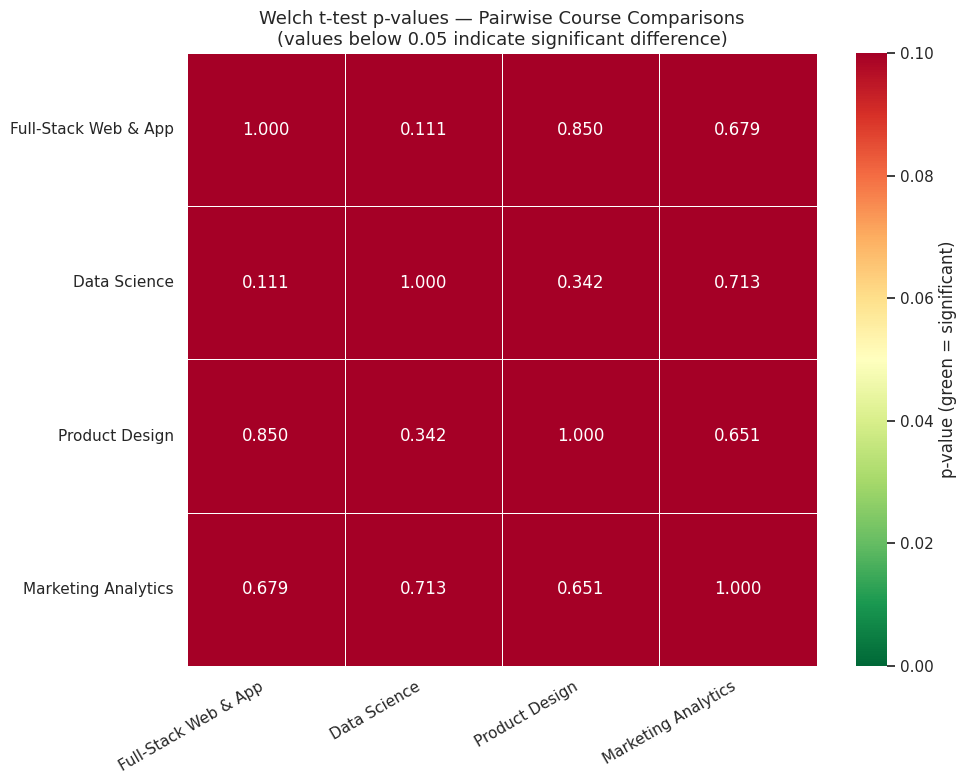

Saved: welch_ttest_heatmap.png
Saved: welch_ttest_results.csv

=== ANALYSIS ===
Significant pairs (p < 0.05): 0 of 6
Non-significant pairs:        6 of 6


In [6]:
# Test whether the difference in average ratings between pairs of courses
# is statistically significant using Welch's t-test.
#
# Why Welch's t-test instead of Student's t-test?
# Welch's t-test does not assume equal variances between groups.
# Since our course groups have very different sample sizes and likely
# different rating variances, Welch's is the appropriate choice.
#
# Interpretation:
#   p-value < 0.05 → the difference is statistically significant
#   p-value >= 0.05 → the difference may be due to chance
#
# We test overall_experience as the primary rating metric.
# Only courses meeting the MIN_REVIEWS threshold are included.

# Filter to courses meeting the minimum threshold
welch_df = df.dropna(subset=['course', 'overall_experience']).copy()
welch_df = welch_df[welch_df['course'].isin(included)]

# Get the rating array for each course
course_groups = {
    course: welch_df[welch_df['course'] == course]['overall_experience'].values
    for course in included
}

print("=== WELCH T-TEST — PAIRWISE COURSE COMPARISONS ===")
print(f"Rating metric: overall_experience")
print(f"Significance threshold: p < 0.05\n")

# Run all pairwise combinations
from itertools import combinations
welch_results = []
for course_a, course_b in combinations(included, 2):
    group_a = course_groups[course_a]
    group_b = course_groups[course_b]
    t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)
    welch_results.append({
        'course_a':     course_a,
        'course_b':     course_b,
        'mean_a':       round(group_a.mean(), 3),
        'mean_b':       round(group_b.mean(), 3),
        'mean_diff':    round(group_a.mean() - group_b.mean(), 3),
        'n_a':          len(group_a),
        'n_b':          len(group_b),
        't_statistic':  round(t_stat, 4),
        'p_value':      round(p_value, 4),
        'significant':  'Yes' if p_value < 0.05 else 'No',
    })

welch_df_results = pd.DataFrame(welch_results).sort_values('p_value')
print(welch_df_results.to_string(index=False))

# Visualize as a heatmap of p-values
pivot_p = pd.DataFrame(index=included, columns=included, dtype=float)
for _, row in welch_df_results.iterrows():
    pivot_p.loc[row['course_a'], row['course_b']] = row['p_value']
    pivot_p.loc[row['course_b'], row['course_a']] = row['p_value']
# Fill diagonal with 1 (comparing a course to itself is always p=1)
for course in included:
    pivot_p.loc[course, course] = 1.0

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot_p.astype(float),
    annot=True, fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0, vmax=0.1,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'p-value (green = significant)'}
)
ax.set_title("Welch t-test p-values — Pairwise Course Comparisons\n(values below 0.05 indicate significant difference)", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'welch_ttest_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: welch_ttest_heatmap.png")

welch_df_results.to_csv(os.path.join(EXPORT_DIR, 'welch_ttest_results.csv'), index=False)
print("Saved: welch_ttest_results.csv")

# Print plain-language analysis
print("\n=== ANALYSIS ===")
sig = welch_df_results[welch_df_results['significant'] == 'Yes']
not_sig = welch_df_results[welch_df_results['significant'] == 'No']
print(f"Significant pairs (p < 0.05): {len(sig)} of {len(welch_df_results)}")
print(f"Non-significant pairs:        {len(not_sig)} of {len(welch_df_results)}")
if len(sig) > 0:
    print("\nSignificant differences found between:")
    for _, row in sig.iterrows():
        direction = "higher" if row['mean_diff'] > 0 else "lower"
        print(f"  {row['course_a']} vs {row['course_b']}: "
              f"mean diff = {row['mean_diff']:+.3f} "
              f"({row['course_a']} is {direction}), "
              f"p = {row['p_value']:.4f}")

# ANOVA

=== ONE-WAY ANOVA RESULTS ===
Courses included: ['Full-Stack Web & App', 'Data Science', 'Product Design', 'Marketing Analytics']
Significance threshold: p < 0.05

            metric  f_statistic  p_value significant                            interpretation
overall_experience       0.8707   0.4561          No No significant difference between courses
            review       1.3209   0.2667          No No significant difference between courses
       instructors       0.7389   0.5297          No No significant difference between courses
        curriculum       3.2563   0.0214         Yes At least one course differs significantly
    job_assistance       0.5693   0.6354          No No significant difference between courses


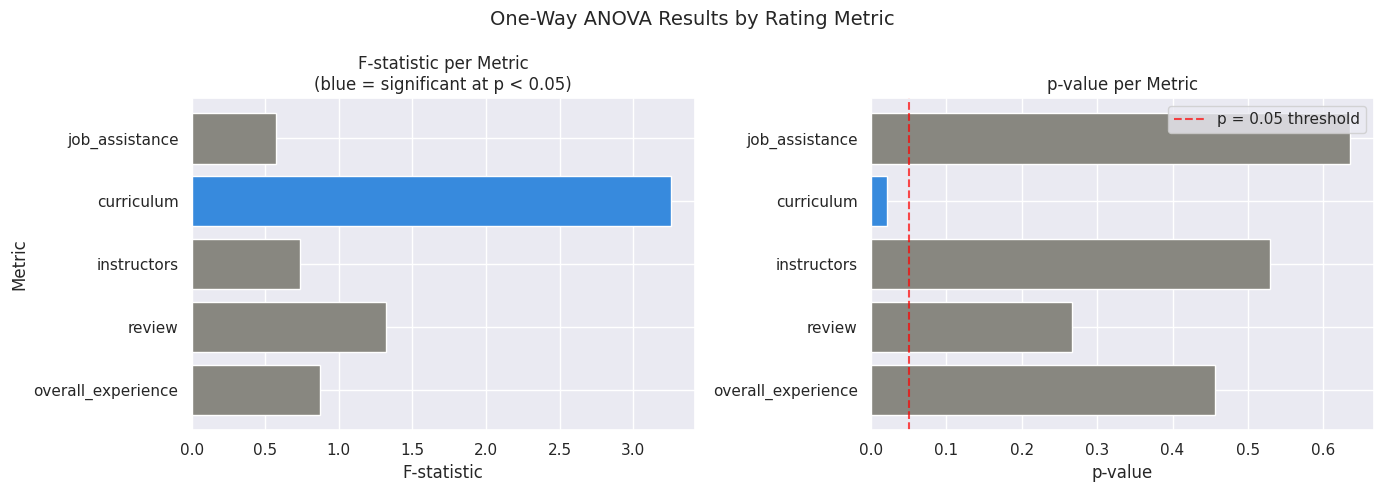

Saved: anova_results.png
Saved: anova_results.csv

=== ANALYSIS ===
  overall_experience: F=0.8707, p=0.4561 → No significant difference between courses
  review: F=1.3209, p=0.2667 → No significant difference between courses
  instructors: F=0.7389, p=0.5297 → No significant difference between courses
  curriculum: F=3.2563, p=0.0214 → At least one course differs significantly
  job_assistance: F=0.5693, p=0.6354 → No significant difference between courses


In [7]:
# Test whether overall_experience ratings differ significantly across ALL
# courses simultaneously using a one-way ANOVA (Analysis of Variance).
#
# Why ANOVA instead of running multiple t-tests?
# Running multiple pairwise t-tests inflates the false positive rate.
# If we run 10 tests at p=0.05 we expect 0.5 false positives by chance alone.
# ANOVA tests the null hypothesis that ALL group means are equal in one test,
# controlling the overall false positive rate at 0.05.
#
# Interpretation:
#   F-statistic: ratio of between-group variance to within-group variance.
#                Higher F = groups are more different from each other
#                relative to the variation within each group.
#   p-value < 0.05 → at least one course mean is significantly different
#                    from the others. Follow up with Tukey HSD to find which.
#   p-value >= 0.05 → no evidence of significant difference between courses.
#
# We also test each individual rating dimension (instructors, curriculum,
# job_assistance) to identify which aspects drive any overall differences.

anova_df = df.dropna(subset=['course', 'overall_experience']).copy()
anova_df = anova_df[anova_df['course'].isin(included)]

print("=== ONE-WAY ANOVA RESULTS ===")
print(f"Courses included: {included}")
print(f"Significance threshold: p < 0.05\n")

anova_results = []
for metric in ['overall_experience', 'review', 'instructors', 'curriculum', 'job_assistance']:
    metric_df = anova_df.dropna(subset=[metric])
    groups    = [
        metric_df[metric_df['course'] == course][metric].values
        for course in included
    ]
    # Remove empty groups
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        continue
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results.append({
        'metric':      metric,
        'f_statistic': round(f_stat, 4),
        'p_value':     round(p_value, 4),
        'significant': 'Yes' if p_value < 0.05 else 'No',
        'interpretation': (
            'At least one course differs significantly'
            if p_value < 0.05 else
            'No significant difference between courses'
        )
    })

anova_results_df = pd.DataFrame(anova_results)
print(anova_results_df.to_string(index=False))

# Visualize F-statistics and p-values side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("One-Way ANOVA Results by Rating Metric", fontsize=14)

colors_anova = ['#378ADD' if p < 0.05 else '#888780' for p in anova_results_df['p_value']]
axes[0].barh(anova_results_df['metric'], anova_results_df['f_statistic'], color=colors_anova)
axes[0].set_title("F-statistic per Metric\n(blue = significant at p < 0.05)")
axes[0].set_xlabel("F-statistic")
axes[0].set_ylabel("Metric")

axes[1].barh(anova_results_df['metric'], anova_results_df['p_value'], color=colors_anova)
axes[1].axvline(0.05, color='red', linestyle='--', alpha=0.7, label='p = 0.05 threshold')
axes[1].set_title("p-value per Metric")
axes[1].set_xlabel("p-value")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'anova_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: anova_results.png")

anova_results_df.to_csv(os.path.join(EXPORT_DIR, 'anova_results.csv'), index=False)
print("Saved: anova_results.csv")

print("\n=== ANALYSIS ===")
for _, row in anova_results_df.iterrows():
    print(f"  {row['metric']}: F={row['f_statistic']}, p={row['p_value']} → {row['interpretation']}")

# Post-Hoc

Running Tukey HSD for significant metrics: ['curriculum']

=== TUKEY HSD — CURRICULUM ===
              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
       group1               group2        meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------
        Data Science Full-Stack Web & App   -0.127 0.0233 -0.2417 -0.0122   True
        Data Science  Marketing Analytics   0.0749 0.9318 -0.2463   0.396  False
        Data Science       Product Design   -0.071 0.9033 -0.3385  0.1965  False
Full-Stack Web & App  Marketing Analytics   0.2018 0.3528 -0.1138  0.5175  False
Full-Stack Web & App       Product Design    0.056 0.9457 -0.2049  0.3169  False
 Marketing Analytics       Product Design  -0.1458 0.7803 -0.5434  0.2517  False
--------------------------------------------------------------------------------


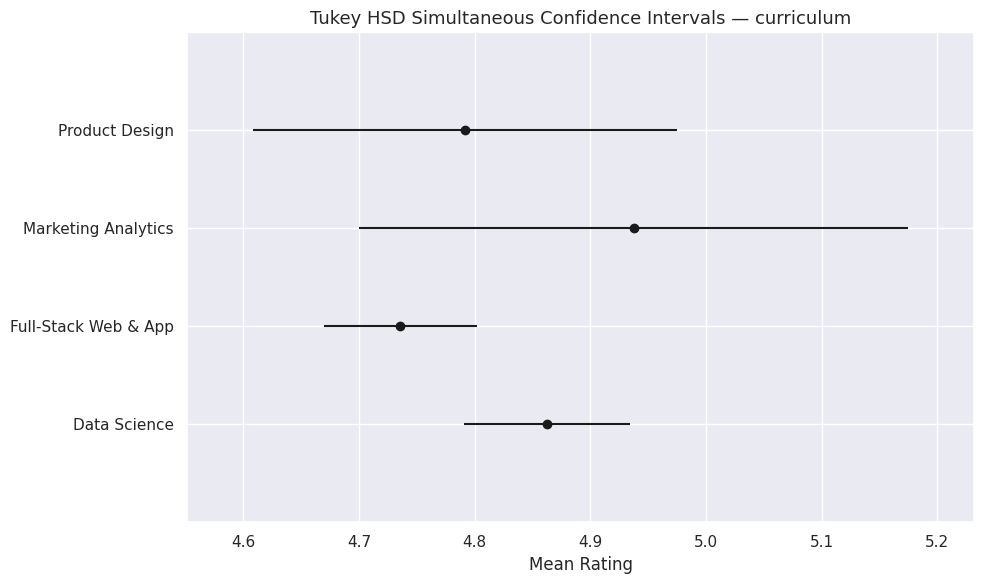

Saved: tukey_hsd_curriculum.png

Saved: tukey_hsd_results.csv

=== ANALYSIS ===

  curriculum — significant pairs:
    Data Science vs Full-Stack Web & App: mean diff = -0.127 (Data Science is lower), p-adj = 0.0233


In [8]:
# Run Tukey HSD (Honestly Significant Difference) post-hoc test to identify
# WHICH specific course pairs differ significantly after ANOVA.
#
# Why Tukey HSD after ANOVA?
# ANOVA only tells us that at least one group mean is different — it does not
# tell us which pairs. Tukey HSD performs all pairwise comparisons while
# controlling the family-wise error rate, making it the standard follow-up
# test after a significant ANOVA result.
#
# We run Tukey HSD on the metrics that showed significant ANOVA results.
# If ANOVA was not significant for a metric, Tukey HSD is not appropriate.
#
# Interpretation:
#   reject = True  → the two courses differ significantly on this metric
#   reject = False → no significant difference between these two courses
#   meandiff       → mean of group1 minus mean of group2

# Identify which metrics had significant ANOVA results
sig_metrics = anova_results_df[anova_results_df['significant'] == 'Yes']['metric'].tolist()

if not sig_metrics:
    print("ANOVA was not significant for any metric. Tukey HSD is not appropriate.")
else:
    print(f"Running Tukey HSD for significant metrics: {sig_metrics}\n")

tukey_all_results = []

for metric in sig_metrics:
    metric_df = anova_df.dropna(subset=[metric]).copy()

    print(f"=== TUKEY HSD — {metric.upper()} ===")
    tukey = pairwise_tukeyhsd(
        endog=metric_df[metric],
        groups=metric_df['course'],
        alpha=0.05
    )
    print(tukey.summary())

    # Extract results into a DataFrame for export
    tukey_summary = pd.DataFrame(
        data=tukey._results_table.data[1:],
        columns=tukey._results_table.data[0]
    )
    tukey_summary.insert(0, 'metric', metric)
    tukey_all_results.append(tukey_summary)

    # Visualize mean differences with confidence intervals
    fig, ax = plt.subplots(figsize=(12, 6))
    tukey.plot_simultaneous(ax=ax)
    ax.set_title(f"Tukey HSD Simultaneous Confidence Intervals — {metric}", fontsize=13)
    ax.set_xlabel("Mean Rating")
    plt.tight_layout()
    plt.savefig(
        os.path.join(CHARTS_DIR, f'tukey_hsd_{metric}.png'),
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"Saved: tukey_hsd_{metric}.png\n")

# Export all Tukey results
if tukey_all_results:
    tukey_export = pd.concat(tukey_all_results, ignore_index=True)
    tukey_export.to_csv(os.path.join(EXPORT_DIR, 'tukey_hsd_results.csv'), index=False)
    print("Saved: tukey_hsd_results.csv")

    print("\n=== ANALYSIS ===")
    for metric in sig_metrics:
        metric_tukey = tukey_export[
            (tukey_export['metric'] == metric) &
            (tukey_export['reject'] == True)
        ]
        print(f"\n  {metric} — significant pairs:")
        if len(metric_tukey) == 0:
            print("    None after correction")
        else:
            for _, row in metric_tukey.iterrows():
                direction = "higher" if float(row['meandiff']) > 0 else "lower"
                print(f"    {row['group1']} vs {row['group2']}: "
                      f"mean diff = {float(row['meandiff']):+.3f} "
                      f"({row['group1']} is {direction}), "
                      f"p-adj = {float(row['p-adj']):.4f}")

# Ratings By Month

=== MONTHLY AVERAGE RATINGS ===
month_str  avg_rating  review_count      std
  2020-02       5.000             4 0.000000
  2020-06       5.000             4 0.000000
  2020-09       5.000             5 0.000000
  2020-10       4.708             6 0.335226
  2020-11       4.480             4 0.274348
  2021-01       4.897             9 0.163478
  2021-02       4.759            16 0.392732
  2021-03       4.692            10 0.514540
  2021-04       4.734             5 0.400350
  2021-05       4.857            13 0.199724
  2021-06       4.812             4 0.375000
  2021-07       4.724             7 0.563142
  2021-08       4.792             6 0.292261
  2021-09       4.462             4 0.394493
  2021-10       4.760             7 0.314696
  2021-12       5.000             7 0.000000
  2022-01       4.675            10 0.943177
  2022-02       4.926            17 0.246296
  2022-03       4.379             7 1.354812
  2022-04       4.875             4 0.250000
  2022-05       5.000  

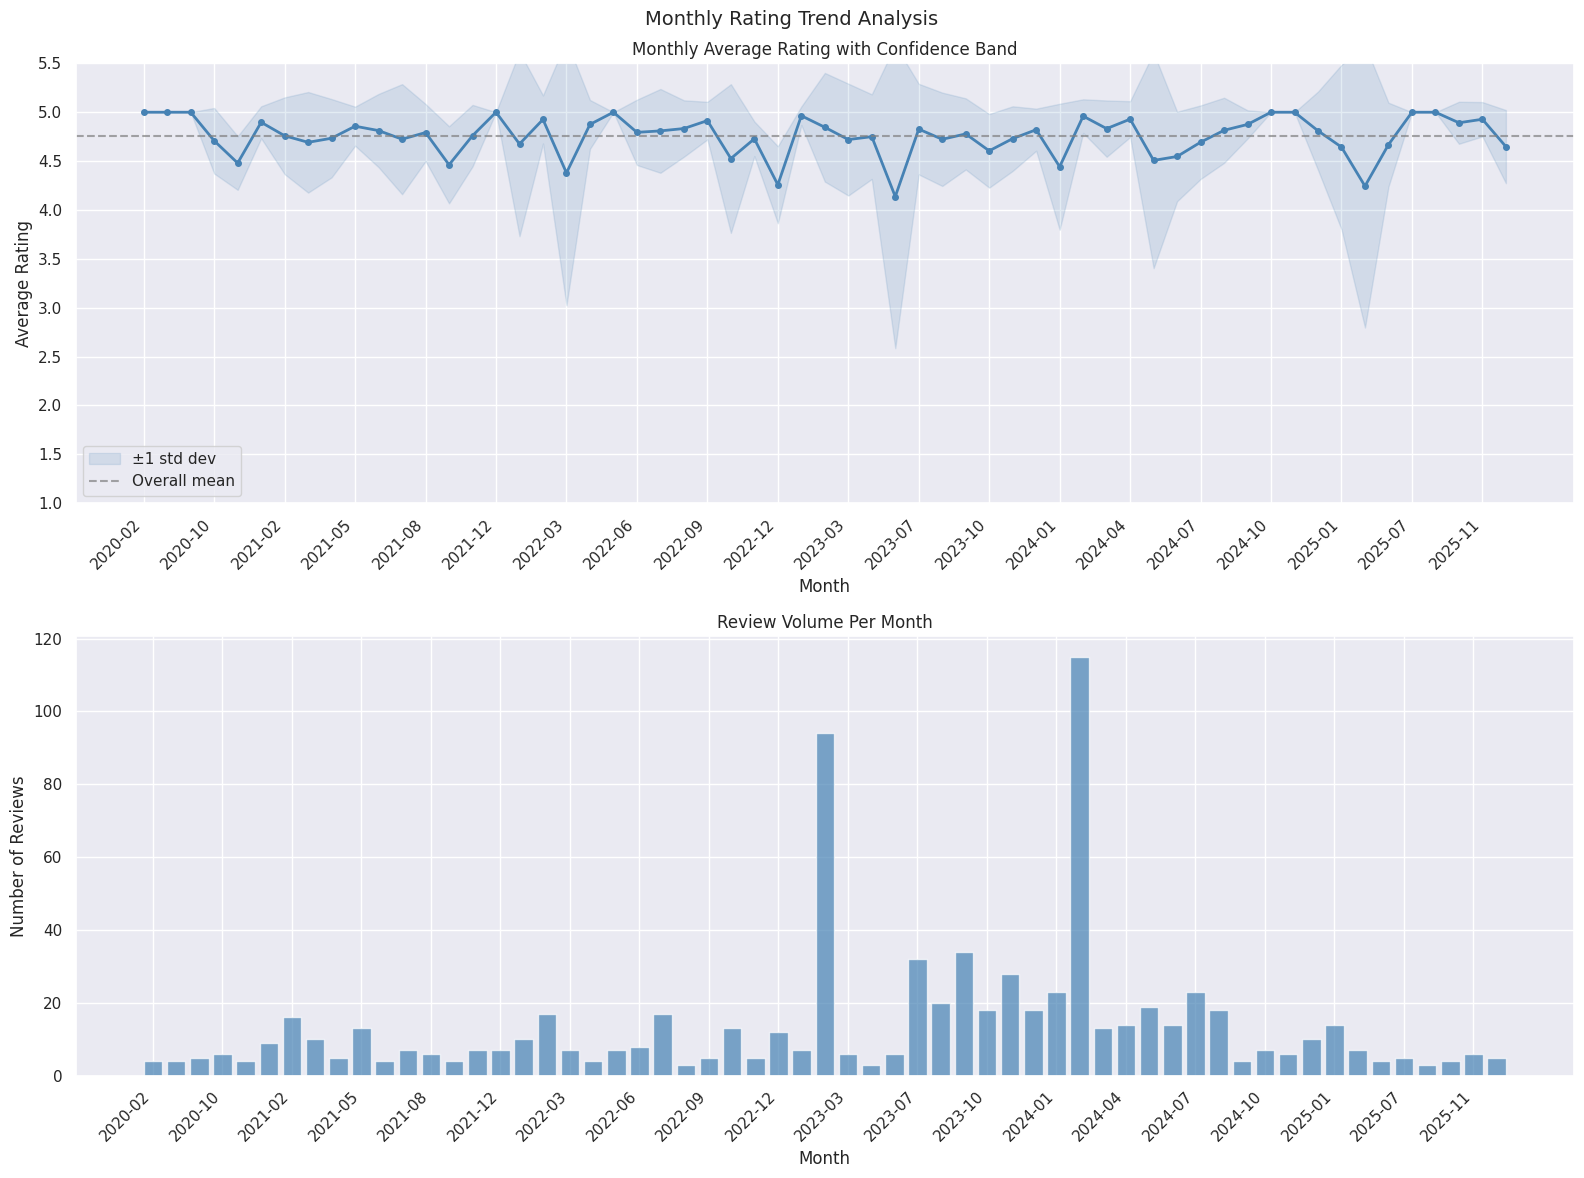

Saved: monthly_rating_trend.png
Saved: monthly_rating_averages.csv


In [9]:
# Calculate average overall_experience rating per month and examine
# whether there is an upward or downward trend over time.
#
# Monthly granularity reveals seasonal patterns or specific periods
# of improvement or decline that yearly averages would smooth over.
# Only months with at least 3 reviews are included to avoid noise
# from months with very sparse data.

monthly_df = df.dropna(subset=['review_month', 'overall_experience']).copy()

# Count reviews per month and apply minimum threshold
monthly_counts = monthly_df['review_month'].value_counts()
valid_months   = monthly_counts[monthly_counts >= 3].index
monthly_df     = monthly_df[monthly_df['review_month'].isin(valid_months)]

# Calculate monthly averages
monthly_avg = (
    monthly_df.groupby('review_month')['overall_experience']
    .agg(['mean', 'count', 'std'])
    .reset_index()
)
monthly_avg.columns = ['month', 'avg_rating', 'review_count', 'std']
monthly_avg = monthly_avg.sort_values('month')
monthly_avg['month_str'] = monthly_avg['month'].astype(str)
monthly_avg['avg_rating'] = monthly_avg['avg_rating'].round(3)

print("=== MONTHLY AVERAGE RATINGS ===")
print(monthly_avg[['month_str', 'avg_rating', 'review_count', 'std']].to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle("Monthly Rating Trend Analysis", fontsize=14)

x = range(len(monthly_avg))

# Monthly average with confidence band (mean ± 1 std)
axes[0].plot(x, monthly_avg['avg_rating'], color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(
    x,
    monthly_avg['avg_rating'] - monthly_avg['std'],
    monthly_avg['avg_rating'] + monthly_avg['std'],
    alpha=0.15, color='steelblue', label='±1 std dev'
)
axes[0].axhline(monthly_avg['avg_rating'].mean(), color='grey', linestyle='--', alpha=0.7, label='Overall mean')
axes[0].set_title("Monthly Average Rating with Confidence Band")
axes[0].set_ylabel("Average Rating")
axes[0].set_xlabel("Month")
axes[0].set_xticks(list(x)[::3])
axes[0].set_xticklabels(monthly_avg['month_str'].tolist()[::3], rotation=45, ha='right')
axes[0].set_ylim(1, 5.5)
axes[0].legend()

# Review volume per month as a bar chart for context
axes[1].bar(x, monthly_avg['review_count'], color='steelblue', alpha=0.7)
axes[1].set_title("Review Volume Per Month")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_xlabel("Month")
axes[1].set_xticks(list(x)[::3])
axes[1].set_xticklabels(monthly_avg['month_str'].tolist()[::3], rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'monthly_rating_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: monthly_rating_trend.png")

monthly_avg.to_csv(os.path.join(EXPORT_DIR, 'monthly_rating_averages.csv'), index=False)
print("Saved: monthly_rating_averages.csv")

# Linear Regression/ Time trends

=== LINEAR TREND ANALYSIS ===
Slope:       -0.00051 rating points per month
R-squared:   0.0018
p-value:     0.7473
Significant: No

Interpretation:
  No statistically significant linear trend detected.
  The slope of -0.00051 per month is not significantly different from zero.

=== MONTH-TO-MONTH DIRECTION COUNTS ===
Months with rating increase: 29
Months with rating decrease: 25
Months unchanged:            4
Net direction: More upward months


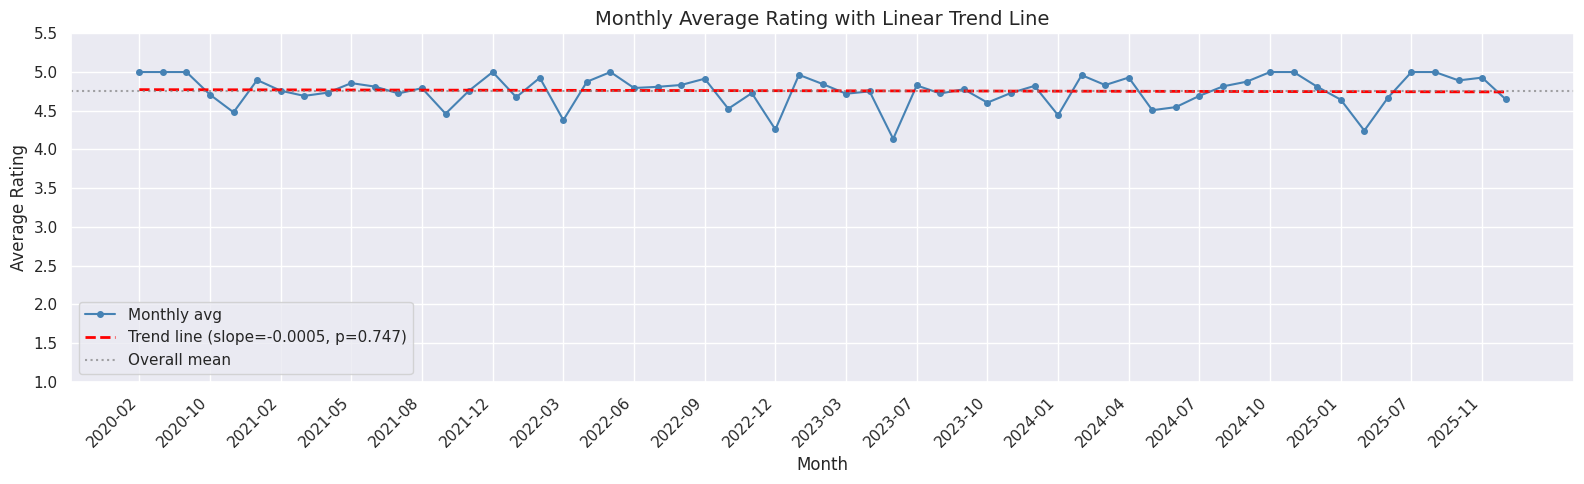

Saved: rating_trend_line.png


In [10]:
# Fit a linear regression to the monthly average ratings to determine
# whether the overall trend is upward, downward, or flat.
#
# We use scipy.stats.linregress which returns:
#   slope:     change in rating per month. Positive = improving, negative = declining.
#   intercept: predicted rating at month 0
#   r_value:   correlation coefficient. Closer to ±1 = stronger linear trend.
#   p_value:   whether the slope is significantly different from zero.
#   stderr:    standard error of the slope estimate.
#
# We also run a Mann-Kendall-style test using the sign of month-to-month
# changes to assess monotonic trend without assuming linearity.

from scipy.stats import linregress, pearsonr

x_numeric = np.arange(len(monthly_avg))
y_ratings = monthly_avg['avg_rating'].values

slope, intercept, r_value, p_value, std_err = linregress(x_numeric, y_ratings)

print("=== LINEAR TREND ANALYSIS ===")
print(f"Slope:       {slope:.5f} rating points per month")
print(f"R-squared:   {r_value**2:.4f}")
print(f"p-value:     {p_value:.4f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")
print(f"\nInterpretation:")
if p_value < 0.05:
    direction = "upward" if slope > 0 else "downward"
    annual    = slope * 12
    print(f"  There is a statistically significant {direction} trend.")
    print(f"  Rating changes by approximately {slope:.4f} points per month")
    print(f"  ({annual:+.3f} points per year at this rate).")
else:
    print(f"  No statistically significant linear trend detected.")
    print(f"  The slope of {slope:.5f} per month is not significantly different from zero.")

# Non-parametric trend: count positive vs negative month-to-month changes
month_changes = np.diff(y_ratings)
n_up   = (month_changes > 0).sum()
n_down = (month_changes < 0).sum()
n_flat = (month_changes == 0).sum()

print(f"\n=== MONTH-TO-MONTH DIRECTION COUNTS ===")
print(f"Months with rating increase: {n_up}")
print(f"Months with rating decrease: {n_down}")
print(f"Months unchanged:            {n_flat}")
print(f"Net direction: {'More upward months' if n_up > n_down else 'More downward months' if n_down > n_up else 'Balanced'}")

# Plot trend line over monthly data
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(x_numeric, y_ratings, color='steelblue', linewidth=1.5, marker='o', markersize=4, label='Monthly avg')
ax.plot(
    x_numeric,
    intercept + slope * x_numeric,
    color='red', linewidth=2, linestyle='--',
    label=f"Trend line (slope={slope:.4f}, p={p_value:.3f})"
)
ax.axhline(y_ratings.mean(), color='grey', linestyle=':', alpha=0.7, label='Overall mean')
ax.set_title("Monthly Average Rating with Linear Trend Line", fontsize=14)
ax.set_ylabel("Average Rating")
ax.set_xlabel("Month")
ax.set_xticks(list(x_numeric)[::3])
ax.set_xticklabels(monthly_avg['month_str'].tolist()[::3], rotation=45, ha='right')
ax.set_ylim(1, 5.5)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'rating_trend_line.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rating_trend_line.png")

# Pos/Neg Frequency by Month

=== TOP 10 NOTABLE MONTH-TO-MONTH SHIFTS ===
month_str  avg_rating  prev_avg  mom_change  review_count
  2023-01       4.964     4.258       0.706             7
  2023-07       4.827     4.137       0.690            32
  2023-05       4.137     4.750      -0.613             6
  2022-03       4.379     4.926      -0.547             7
  2024-02       4.960     4.442       0.518           115
  2022-04       4.875     4.379       0.496             4
  2022-12       4.258     4.728      -0.470            12
  2025-06       4.668     4.244       0.424             4
  2024-05       4.507     4.929      -0.422            19
  2021-01       4.897     4.480       0.417             9


/tmp/ipykernel_2175/2697731193.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_avg_changes['abs_change'] = monthly_avg_changes['mom_change'].abs()


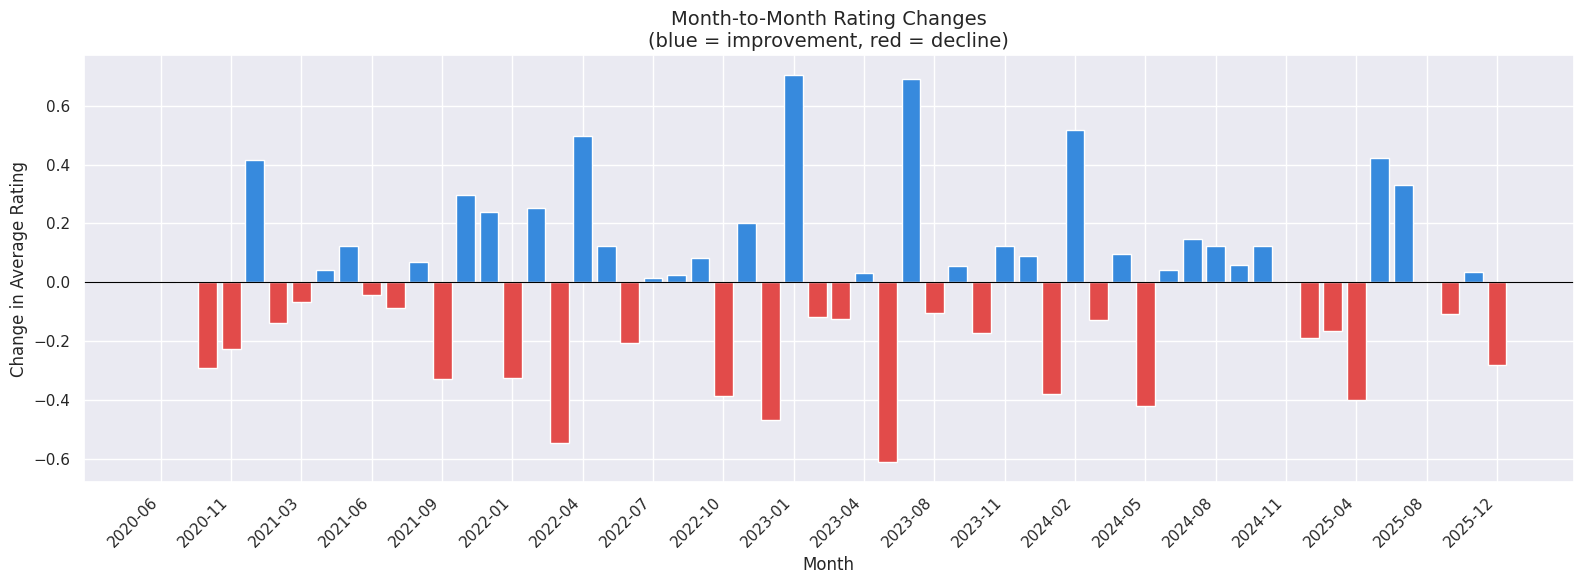

Saved: month_to_month_changes.png

=== TOP 3 LARGEST POSITIVE SHIFTS ===

Month: 2023-01 | Change: +0.706 | n=7
  Kaj Kandler  | Data Science | Rating: 5.0
  Intense Learning, Awesome Team: WBS delivered on what it promised. The 15 weeks gave me an intense learning curve through Data Science, starting from major Python libraries like pandas and scikit-lear
  Rene Markovits Hoopii  | Data Science | Rating: 4.75
  most effective way of learning data science: Right in front I want to say something on my overall experience: I'm so happy I chose WBS Coding School to help me make the transition in the field of data
  Liane Gybas  | Data Science | Rating: 5.0
  Amazing learning curve: I came to the Bootcamp to learn to use Python in Machine Learning / Data Science. I chose this course because I needed an online class, I wanted a teacher to be available, and 

Month: 2023-07 | Change: +0.690 | n=32
  Miroslav Ljubicic  | Full-Stack Web & App | Rating: 5.0
  best learning experience: WBS Coding

In [11]:
# Identify the months with the largest positive and negative month-to-month
# changes in average rating. These are the most actionable data points because
# they indicate specific moments in time when the student experience shifted
# significantly — either improving or deteriorating.
#
# For each notable shift we print the month, the change magnitude, and the
# reviews from that month so the shift can be investigated qualitatively.

# Calculate month-to-month changes
monthly_avg['prev_avg']   = monthly_avg['avg_rating'].shift(1)
monthly_avg['mom_change'] = (monthly_avg['avg_rating'] - monthly_avg['prev_avg']).round(3)
monthly_avg_changes       = monthly_avg.dropna(subset=['mom_change'])

# Sort by absolute change to find the most notable shifts
monthly_avg_changes['abs_change'] = monthly_avg_changes['mom_change'].abs()
top_shifts = monthly_avg_changes.nlargest(10, 'abs_change')

print("=== TOP 10 NOTABLE MONTH-TO-MONTH SHIFTS ===")
print(top_shifts[['month_str', 'avg_rating', 'prev_avg', 'mom_change', 'review_count']].to_string(index=False))

# Visualize month-to-month changes as a diverging bar chart
fig, ax = plt.subplots(figsize=(16, 6))
colors_shifts = ['#378ADD' if c > 0 else '#E24B4A' for c in monthly_avg_changes['mom_change']]
x_shifts = range(len(monthly_avg_changes))
ax.bar(x_shifts, monthly_avg_changes['mom_change'], color=colors_shifts)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Month-to-Month Rating Changes\n(blue = improvement, red = decline)", fontsize=14)
ax.set_ylabel("Change in Average Rating")
ax.set_xlabel("Month")
ax.set_xticks(list(x_shifts)[::3])
ax.set_xticklabels(monthly_avg_changes['month_str'].tolist()[::3], rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'month_to_month_changes.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: month_to_month_changes.png")

# Print the reviews from the top 3 largest positive and negative shifts
print("\n=== TOP 3 LARGEST POSITIVE SHIFTS ===")
for _, shift in monthly_avg_changes.nlargest(3, 'mom_change').iterrows():
    month_reviews = df[df['review_month'] == shift['month']][
        ['author', 'course', 'overall_experience', 'text_for_analysis']
    ]
    print(f"\nMonth: {shift['month_str']} | Change: {shift['mom_change']:+.3f} | n={int(shift['review_count'])}")
    for _, rev in month_reviews.head(3).iterrows():
        print(f"  {rev['author']} | {rev['course']} | Rating: {rev['overall_experience']}")
        print(f"  {str(rev['text_for_analysis'])[:200]}")

print("\n=== TOP 3 LARGEST NEGATIVE SHIFTS ===")
for _, shift in monthly_avg_changes.nsmallest(3, 'mom_change').iterrows():
    month_reviews = df[df['review_month'] == shift['month']][
        ['author', 'course', 'overall_experience', 'text_for_analysis']
    ]
    print(f"\nMonth: {shift['month_str']} | Change: {shift['mom_change']:+.3f} | n={int(shift['review_count'])}")
    for _, rev in month_reviews.head(3).iterrows():
        print(f"  {rev['author']} | {rev['course']} | Rating: {rev['overall_experience']}")
        print(f"  {str(rev['text_for_analysis'])[:200]}")

monthly_avg_changes.to_csv(os.path.join(EXPORT_DIR, 'monthly_changes.csv'), index=False)
print("\nSaved: monthly_changes.csv")

# Determine Topics for Modeling

TF-IDF matrix shape: (818, 1000)
Testing NMF reconstruction error for n_topics 2 to 15...
  n_topics= 2  reconstruction_error=27.6942
  n_topics= 3  reconstruction_error=27.5444
  n_topics= 4  reconstruction_error=27.4076
  n_topics= 5  reconstruction_error=27.2800
  n_topics= 6  reconstruction_error=27.1567
  n_topics= 7  reconstruction_error=27.0408
  n_topics= 8  reconstruction_error=26.9422
  n_topics= 9  reconstruction_error=26.8425
  n_topics=10  reconstruction_error=26.7510
  n_topics=11  reconstruction_error=26.6587
  n_topics=12  reconstruction_error=26.5687
  n_topics=13  reconstruction_error=26.4785
  n_topics=14  reconstruction_error=26.3895
  n_topics=15  reconstruction_error=26.3054


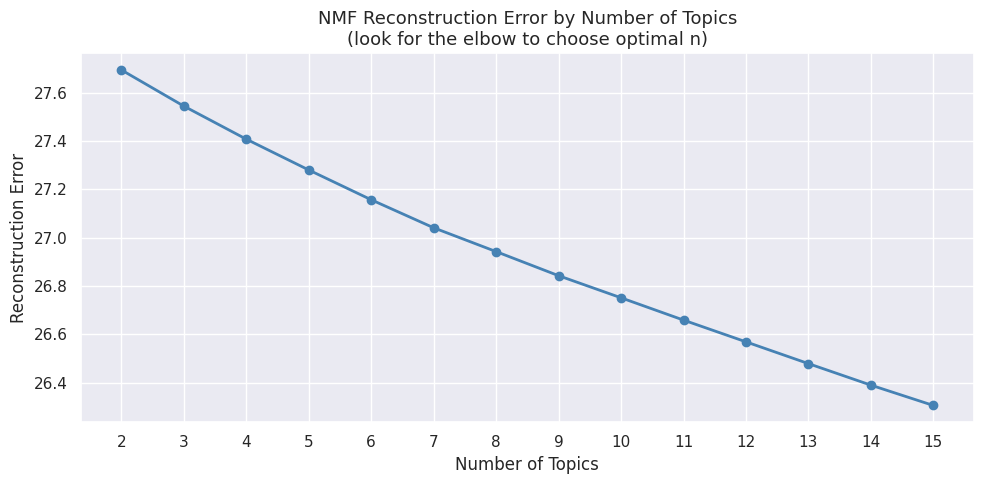

Saved: nmf_elbow_curve.png

Recommended number of topics based on elbow: 3
You can override this by setting N_TOPICS manually in the next cell.


In [12]:
# Before fitting the NMF topic model we need to determine the optimal number
# of topics. Too few topics and distinct themes get merged together. Too many
# and topics become repetitive or incoherent.
#
# We use reconstruction error to guide this decision.
# NMF minimizes the difference between the original TF-IDF matrix and its
# low-rank approximation. As we increase the number of topics the reconstruction
# error decreases. We look for the "elbow" — the point where adding more topics
# produces diminishing returns in reconstruction quality.
#
# We test n_topics from 2 to 15 and plot the reconstruction error curve.

TFIDF_STOPWORDS = [
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "is", "was", "it", "i", "my", "me", "we", "our", "you",
    "your", "they", "their", "this", "that", "have", "had", "has", "be",
    "been", "are", "were", "not", "so", "as", "from", "by", "all", "very",
    "also", "more", "about", "which", "would", "could", "will", "what",
    "who", "how", "when", "there", "than", "just", "after", "during",
    "its", "if", "up", "out", "do", "did", "get", "got", "one", "can",
    "even", "really", "much", "well", "him", "her", "his", "she", "he",
    "into", "through", "while", "these", "those", "then", "only", "any",
    "each", "such", "over", "am", "wbs", "coding", "school", "bootcamp",
    "boot", "camp", "course", "program", "web", "development", "developer",
    "app", "stack", "full", "weeks", "week", "month", "months", "time",
    "class", "learn", "learned", "learning", "study", "studied",
    "experience", "highly", "recommend", "great", "good", "amazing",
    "excellent", "everything", "other", "students", "student", "thing",
    "things", "told", "instructor", "instructors", "job", "jobs", "always",
    "lot", "data", "science", "career", "new", "made", "make", "work",
    "working", "take", "took", "start", "started", "know", "like",
    "feel", "felt", "re", "ve", "ll", "didn", "don", "isn", "wasn",
    "und", "15",
]

# Fit TF-IDF on all review text
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words=TFIDF_STOPWORDS,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(
    df['text_for_analysis'].fillna("")
)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print("Testing NMF reconstruction error for n_topics 2 to 15...")

# Calculate reconstruction error for each n_topics value
n_topics_range = range(2, 16)
errors = []
for n in n_topics_range:
    nmf = NMF(n_components=n, random_state=42, max_iter=500)
    nmf.fit(tfidf_matrix)
    errors.append(nmf.reconstruction_err_)
    print(f"  n_topics={n:2d}  reconstruction_error={nmf.reconstruction_err_:.4f}")

# Plot the elbow curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(n_topics_range), errors, marker='o', color='steelblue', linewidth=2)
ax.set_title("NMF Reconstruction Error by Number of Topics\n(look for the elbow to choose optimal n)", fontsize=13)
ax.set_xlabel("Number of Topics")
ax.set_ylabel("Reconstruction Error")
ax.set_xticks(list(n_topics_range))

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'nmf_elbow_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nmf_elbow_curve.png")

# Calculate the change in error between each step to find the elbow
error_changes = [errors[i] - errors[i+1] for i in range(len(errors)-1)]
elbow_idx     = error_changes.index(max(error_changes))
recommended_n = list(n_topics_range)[elbow_idx + 1]
print(f"\nRecommended number of topics based on elbow: {recommended_n}")
print("You can override this by setting N_TOPICS manually in the next cell.")

# Non-negative Matrix Factorization

Fitting NMF with 3 topics...

=== TOP 10 WORDS PER TOPIC ===

Topic 1: best, people, staff, community, team, some, help, group, support, no

Topic 2: completed, skills, curriculum, recently, recently completed, world, real, hands, projects, supportive

Topic 3: campus, phase, campus phase, marketing, analytics, marketing analytics, berlin, online, nice, two

=== DOMINANT TOPIC DISTRIBUTION ===
dominant_topic
1    420
2    282
3    116


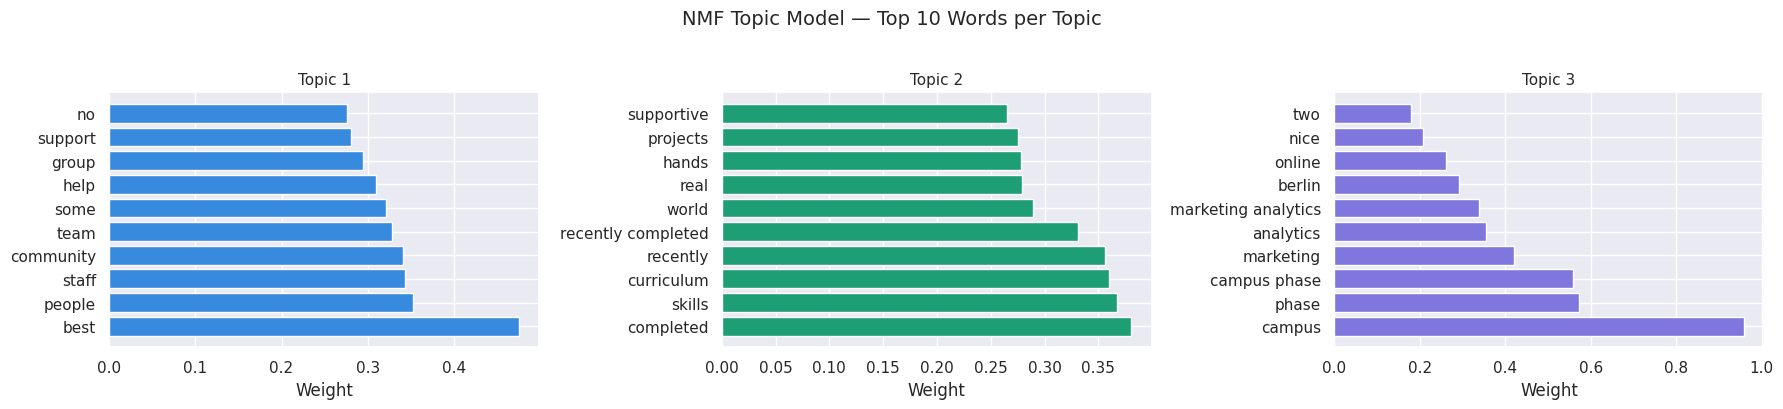

Saved: nmf_topic_words.png
Saved: topic_word_weights.csv


In [13]:
# Fit the final NMF topic model using the optimal number of topics
# identified in the elbow curve analysis.
#
# NMF (Non-negative Matrix Factorization) decomposes the TF-IDF matrix into:
#   W: document-topic matrix — how strongly each review relates to each topic
#   H: topic-word matrix — which words define each topic
#
# Each topic is represented as a weighted list of its most important words.
# We assign each review its dominant topic — the topic with the highest
# weight in that review's row of W.
#
# Topics are given interpretive labels based on their top words.
# These labels are set manually after inspecting the top words per topic.

# Set number of topics — override recommended_n here if needed
N_TOPICS = recommended_n
print(f"Fitting NMF with {N_TOPICS} topics...")

nmf_model   = NMF(n_components=N_TOPICS, random_state=42, max_iter=500)
W           = nmf_model.fit_transform(tfidf_matrix)
H           = nmf_model.components_
terms       = tfidf_vectorizer.get_feature_names_out()
N_TOP_WORDS = 10

print(f"\n=== TOP {N_TOP_WORDS} WORDS PER TOPIC ===")
topic_word_data = []
for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[:-N_TOP_WORDS-1:-1]
    top_words   = [terms[i] for i in top_indices]
    top_weights = [round(topic[i], 4) for i in top_indices]
    print(f"\nTopic {topic_idx + 1}: {', '.join(top_words)}")
    topic_word_data.append({
        'topic':       topic_idx + 1,
        'top_words':   ', '.join(top_words),
        'top_weights': ', '.join(str(w) for w in top_weights),
    })

# Assign dominant topic to each review
dominant_topics = W.argmax(axis=1) + 1
df['dominant_topic'] = dominant_topics
df['topic_weight']   = W.max(axis=1).round(4)

print(f"\n=== DOMINANT TOPIC DISTRIBUTION ===")
print(df['dominant_topic'].value_counts().sort_index().to_string())

# Visualize topic word weights as horizontal bar charts
n_cols  = min(3, N_TOPICS)
n_rows  = (N_TOPICS + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

colors_topics = ['#378ADD', '#1D9E75', '#7F77DD', '#BA7517', '#D85A30',
                 '#E24B4A', '#888780', '#639922', '#534AB7', '#0F6E56']

for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[:-N_TOP_WORDS-1:-1][::-1]
    top_words   = [terms[i] for i in top_indices]
    top_weights = [topic[i] for i in top_indices]
    color       = colors_topics[topic_idx % len(colors_topics)]
    axes[topic_idx].barh(top_words, top_weights, color=color)
    axes[topic_idx].set_title(f"Topic {topic_idx + 1}", fontsize=11, fontweight='500')
    axes[topic_idx].invert_yaxis()
    axes[topic_idx].set_xlabel("Weight")

# Hide unused subplots
for i in range(N_TOPICS, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f"NMF Topic Model — Top {N_TOP_WORDS} Words per Topic", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'nmf_topic_words.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nmf_topic_words.png")

topic_word_df = pd.DataFrame(topic_word_data)
topic_word_df.to_csv(os.path.join(EXPORT_DIR, 'topic_word_weights.csv'), index=False)
print("Saved: topic_word_weights.csv")

# Topic Distribution

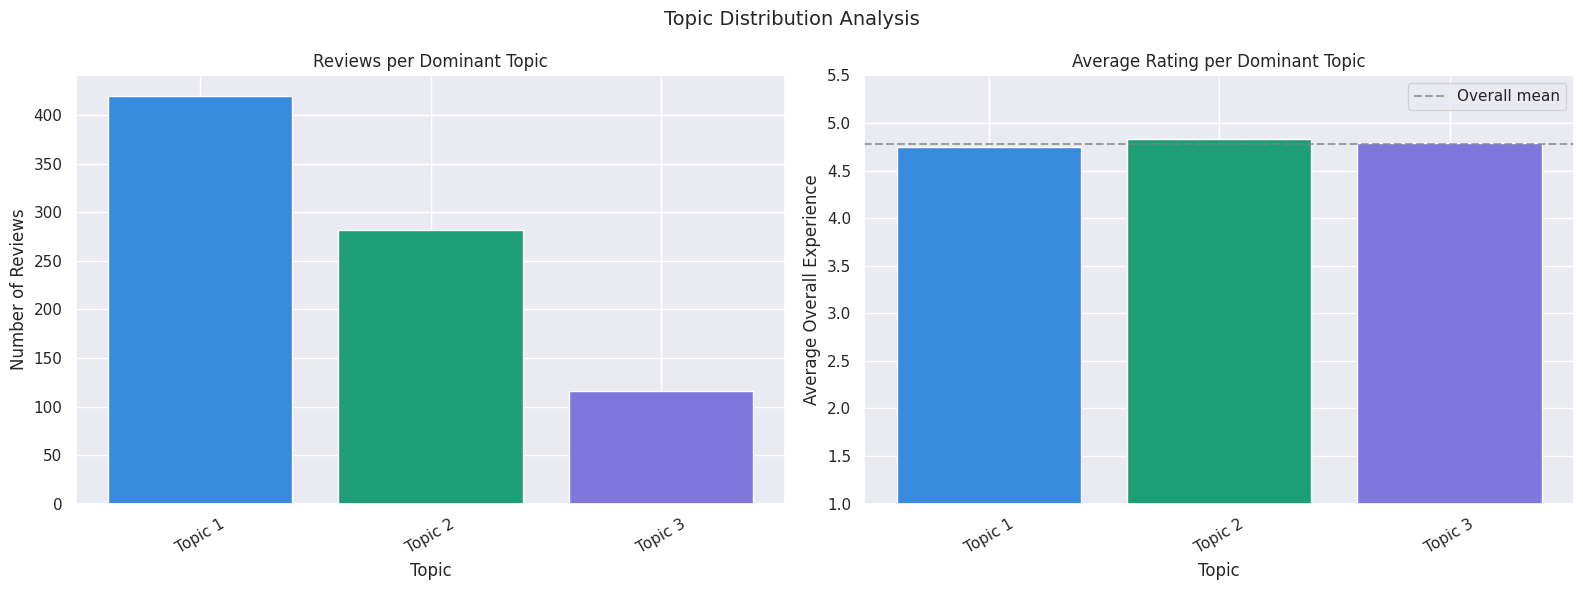

Saved: topic_distribution.png

=== SAMPLE REVIEWS PER TOPIC ===
Use these to assign interpretive labels to each topic.


TOPIC 1 — top words: best, people, staff, community, team, some, help, group, support, no
  [Data Science] An EPIC Experience: After navigating through some tough personal times, the Data Science Bootcamp at WBS Coding School gave my life a new foundation and a new direction!From my first contact with the company, I felt welcomed, accepted and cared for. 

  [Data Science] "An EPIC experience": After navigating through some tough personal times, the Data Science Bootcamp at WBS Coding School gave my life a new foundation and a new direction!From my first contact with the company, I felt welcomed, accepted and cared for

  [Data Science] most effective way of learning data science: Right in front I want to say something on my overall experience: I'm so happy I chose WBS Coding School to help me make the transition in the field of data. Not once during this heavy load 

In [14]:
# Examine how topics are distributed across reviews, courses, and rating groups.
# This reveals which topics are most common and whether certain topics are
# associated with positive or negative experiences.
#
# We also print sample reviews from each topic to help with manual labelling
# of topic names. Reading actual reviews is essential for interpreting what
# each topic really represents beyond just its top words.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Topic Distribution Analysis", fontsize=14)

# Count of reviews per dominant topic
topic_counts = df['dominant_topic'].value_counts().sort_index().reset_index()
topic_counts.columns = ['topic', 'count']
topic_labels = [f"Topic {t}" for t in topic_counts['topic']]
bar_colors   = [colors_topics[(t-1) % len(colors_topics)] for t in topic_counts['topic']]

axes[0].bar(topic_labels, topic_counts['count'], color=bar_colors)
axes[0].set_title("Reviews per Dominant Topic")
axes[0].set_xlabel("Topic")
axes[0].set_ylabel("Number of Reviews")
axes[0].tick_params(axis='x', rotation=30)

# Average overall_experience rating per topic
topic_ratings = df.dropna(subset=['overall_experience']).groupby('dominant_topic')['overall_experience'].mean().reset_index()
topic_ratings.columns = ['topic', 'avg_rating']
rating_labels = [f"Topic {t}" for t in topic_ratings['topic']]
rating_colors = [colors_topics[(t-1) % len(colors_topics)] for t in topic_ratings['topic']]

axes[1].bar(rating_labels, topic_ratings['avg_rating'], color=rating_colors)
axes[1].axhline(df['overall_experience'].mean(), color='grey', linestyle='--', alpha=0.7, label='Overall mean')
axes[1].set_title("Average Rating per Dominant Topic")
axes[1].set_xlabel("Topic")
axes[1].set_ylabel("Average Overall Experience")
axes[1].set_ylim(1, 5.5)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'topic_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: topic_distribution.png")

# Print 3 sample reviews per topic to help with manual labelling
print("\n=== SAMPLE REVIEWS PER TOPIC ===")
print("Use these to assign interpretive labels to each topic.\n")
for topic_num in sorted(df['dominant_topic'].unique()):
    topic_reviews = df[df['dominant_topic'] == topic_num].nlargest(3, 'topic_weight')
    top_words     = topic_word_data[topic_num - 1]['top_words']
    print(f"\nTOPIC {topic_num} — top words: {top_words}")
    print(f"{'='*70}")
    for _, row in topic_reviews.iterrows():
        print(f"  [{row['course']}] {str(row['text_for_analysis'])[:250]}")
        print()

# Export reviews with dominant topic assigned
df[['author', 'course', 'overall_experience', 'dominant_topic',
    'topic_weight', 'text_for_analysis']].to_csv(
    os.path.join(EXPORT_DIR, 'reviews_with_topics.csv'), index=False
)
print("Saved: reviews_with_topics.csv")

# Summary Export

In [15]:
# Compile all statistical findings into a single summary report CSV.
# This brings together the key results from every analysis cell
# into one file that can be shared with stakeholders or imported
# into the Looker Studio dashboard.

report_rows = []

# Minimum threshold finding
report_rows.append({
    'section': 'Threshold Analysis',
    'finding': f"Minimum review threshold set to {MIN_REVIEWS} reviews per course",
    'detail':  f"Included: {', '.join(included)}. Excluded: {', '.join(excluded) if excluded else 'none'}",
})

# Yearly rating trend
best_year  = yearly_avg.loc[yearly_avg['overall_experience'].idxmax(), 'review_year']
worst_year = yearly_avg.loc[yearly_avg['overall_experience'].idxmin(), 'review_year']
report_rows.append({
    'section': 'Ratings by Year',
    'finding': f"Best year: {best_year} ({yearly_avg['overall_experience'].max():.3f}), Worst year: {worst_year} ({yearly_avg['overall_experience'].min():.3f})",
    'detail':  f"Range: {yearly_avg['overall_experience'].max() - yearly_avg['overall_experience'].min():.3f} rating points",
})

# Welch t-test
sig_pairs = welch_df_results[welch_df_results['significant'] == 'Yes']
report_rows.append({
    'section': 'Welch t-test',
    'finding': f"{len(sig_pairs)} of {len(welch_df_results)} pairwise comparisons are statistically significant (p < 0.05)",
    'detail':  '; '.join([f"{r['course_a']} vs {r['course_b']} (p={r['p_value']:.4f})" for _, r in sig_pairs.iterrows()]) if len(sig_pairs) > 0 else 'No significant pairs',
})

# ANOVA
for _, row in anova_results_df.iterrows():
    report_rows.append({
        'section': 'ANOVA',
        'finding': f"{row['metric']}: F={row['f_statistic']}, p={row['p_value']} — {row['interpretation']}",
        'detail':  'Significant' if row['significant'] == 'Yes' else 'Not significant',
    })

# Linear trend
report_rows.append({
    'section': 'Time Trend',
    'finding': f"Linear slope: {slope:.5f} per month (p={p_value:.4f})",
    'detail':  f"{'Significant ' + ('upward' if slope > 0 else 'downward') + ' trend' if p_value < 0.05 else 'No significant trend detected'}. {n_up} months up, {n_down} months down.",
})

# Topic modeling
report_rows.append({
    'section': 'Topic Modeling',
    'finding': f"{N_TOPICS} topics extracted using NMF on TF-IDF matrix",
    'detail':  '; '.join([f"Topic {r['topic']}: {r['top_words'][:50]}" for r in topic_word_data]),
})

report_df = pd.DataFrame(report_rows)
report_path = os.path.join(EXPORT_DIR, 'statistical_analysis_report.csv')
report_df.to_csv(report_path, index=False)

print("=== STATISTICAL ANALYSIS REPORT ===")
for _, row in report_df.iterrows():
    print(f"\n[{row['section']}]")
    print(f"  {row['finding']}")
    print(f"  {row['detail']}")

print(f"\nSaved: statistical_analysis_report.csv")
print(f"\nAll exports saved to: {EXPORT_DIR}")
print(f"All charts saved to:  {CHARTS_DIR}")
print("\nFiles saved:")
for f in sorted(os.listdir(CHARTS_DIR)):
    if f.endswith('.png'):
        print(f"  {f}")
print("\nExports saved:")
for f in sorted(os.listdir(EXPORT_DIR)):
    if f.endswith('.csv'):
        print(f"  {f}")

=== STATISTICAL ANALYSIS REPORT ===

[Threshold Analysis]
  Minimum review threshold set to 10 reviews per course
  Included: Full-Stack Web & App, Data Science, Product Design, Marketing Analytics. Excluded: Full-Stack PHP Development

[Ratings by Year]
  Best year: 2020.0 (4.854), Worst year: 2022.0 (4.707)
  Range: 0.147 rating points

[Welch t-test]
  0 of 6 pairwise comparisons are statistically significant (p < 0.05)
  No significant pairs

[ANOVA]
  overall_experience: F=0.8707, p=0.4561 — No significant difference between courses
  Not significant

[ANOVA]
  review: F=1.3209, p=0.2667 — No significant difference between courses
  Not significant

[ANOVA]
  instructors: F=0.7389, p=0.5297 — No significant difference between courses
  Not significant

[ANOVA]
  curriculum: F=3.2563, p=0.0214 — At least one course differs significantly
  Significant

[ANOVA]
  job_assistance: F=0.5693, p=0.6354 — No significant difference between courses
  Not significant

[Time Trend]
  Linear sl

In [16]:
import pandas as pd
from pathlib import Path

DASHBOARD_PATH  = '/content/drive/Shareddrives/essentis_intern_drive/data/processed/dashboard_master.csv'
STAT_EXPORT_DIR = '/content/drive/Shareddrives/essentis_intern_drive/charts/statistical/exports'

dashboard_df = pd.read_csv(DASHBOARD_PATH)
print(f"Loaded dashboard_master.csv: {dashboard_df.shape}")

STATISTICAL_COLS = ['dominant_topic', 'topic_weight']
available_cols   = [c for c in STATISTICAL_COLS if c in df.columns]

merge_df = df[['author', 'review_text'] + available_cols].copy()

dashboard_df = dashboard_df.drop(columns=available_cols, errors='ignore')
dashboard_df = dashboard_df.merge(
    merge_df,
    on=['author', 'review_text'],
    how='left'
)

print(f"Updated shape: {dashboard_df.shape}")
dashboard_df.to_csv(DASHBOARD_PATH, index=False)
print(f"Saved: dashboard_master.csv")

os.makedirs(STAT_EXPORT_DIR, exist_ok=True)

report_rows = []
report_rows.append({
    'section': 'Threshold Analysis',
    'finding': f"Minimum review threshold: {MIN_REVIEWS} reviews per course",
    'detail':  f"Included: {', '.join(included)}. Excluded: {', '.join(excluded) if excluded else 'none'}",
})
report_rows.append({
    'section': 'Ratings by Year',
    'finding': f"Best year: {yearly_avg.loc[yearly_avg['overall_experience'].idxmax(), 'review_year']} ({yearly_avg['overall_experience'].max():.3f})",
    'detail':  f"Worst year: {yearly_avg.loc[yearly_avg['overall_experience'].idxmin(), 'review_year']} ({yearly_avg['overall_experience'].min():.3f})",
})
sig_pairs = welch_df_results[welch_df_results['significant'] == 'Yes']
report_rows.append({
    'section': 'Welch t-test',
    'finding': f"{len(sig_pairs)} of {len(welch_df_results)} pairs significant (p < 0.05)",
    'detail':  '; '.join([f"{r['course_a']} vs {r['course_b']} p={r['p_value']:.4f}" for _, r in sig_pairs.iterrows()]) if len(sig_pairs) > 0 else 'No significant pairs',
})
for _, row in anova_results_df.iterrows():
    report_rows.append({
        'section': 'ANOVA',
        'finding': f"{row['metric']}: F={row['f_statistic']} p={row['p_value']}",
        'detail':  row['interpretation'],
    })
report_rows.append({
    'section': 'Time Trend',
    'finding': f"Slope: {slope:.5f} per month (p={p_value:.4f})",
    'detail':  f"{'Significant ' + ('upward' if slope > 0 else 'downward') + ' trend' if p_value < 0.05 else 'No significant trend'}. {n_up} months up, {n_down} months down.",
})
report_rows.append({
    'section': 'Topic Modeling',
    'finding': f"{N_TOPICS} topics extracted using NMF",
    'detail':  '; '.join([f"Topic {r['topic']}: {r['top_words'][:60]}" for r in topic_word_data]),
})

pd.DataFrame(report_rows).to_csv(
    os.path.join(STAT_EXPORT_DIR, 'statistical_analysis_report.csv'), index=False
)

print(f"\nAlso saved: statistical_analysis_report.csv")
print(f"\n=== FINAL DASHBOARD MASTER ===")
print(f"Shape: {dashboard_df.shape}")
print(f"Columns ({len(dashboard_df.columns)}):")
for col in dashboard_df.columns:
    print(f"  {col}")

Loaded dashboard_master.csv: (839, 56)
Updated shape: (839, 58)
Saved: dashboard_master.csv

Also saved: statistical_analysis_report.csv

=== FINAL DASHBOARD MASTER ===
Shape: (839, 58)
Columns (58):
  batch_id
  author
  data_source
  source
  review_date
  overall_experience
  review
  instructors
  curriculum
  job_assistance
  review_text
  review_text_translated
  course_format
  course
  role
  verified
  verification_source
  link
  text_for_analysis
  sentiment_compound
  sentiment_pos
  sentiment_neg
  sentiment_neu
  sentiment_label
  review_length_chars
  review_length_words
  review_year
  review_month
  verified_label
  aspect_teaching_quality
  aspect_curriculum
  aspect_career_support
  aspect_community
  aspect_course_pace
  aspect_value_for_money
  aspect_online_experience
  aspect_support_and_staff
  aspect_hardware_and_setup
  aspect_outcomes
  motivation_career_change
  motivation_job_outcomes
  motivation_curriculum_quality
  motivation_flexibility
  motivation_rep